In [57]:
import polars as pl
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

BASE_PATH = os.path.abspath(os.path.join(".."))
OUTPUT_PATH = os.path.join(BASE_PATH, "output")

In [58]:
year = 2024

csee = f"{BASE_PATH}/data/GNFR F/temporal-profiles/GNFR_F_cold_timeprofile_{year}.csv"

hot = f"{BASE_PATH}/data/GNFR F/temporal-profiles/GNFR_F_hot_timeprofile_{year}.csv"

path_output = f"{BASE_PATH}/output/{year}/temporal-profiles/GNFR_F/"

In [59]:
_df_csee = pl.read_csv(csee, try_parse_dates=True) \
    .with_columns(pl.col("timestamp").dt.replace_time_zone("Europe/Berlin", ambiguous="earliest", non_existent="null").dt.convert_time_zone('UTC'))
    
    
_df_hot = pl.read_csv(hot, try_parse_dates=True) \
    .with_columns(pl.col("timestamp").dt.replace_time_zone("Europe/Berlin", ambiguous="earliest", non_existent="null").dt.convert_time_zone('UTC'))

date_range = pl.DataFrame({"timestamp": pl.datetime_range(
    start=datetime(year, 1, 1, 0, 0, 0),
    end=datetime(year, 12, 31, 23, 0, 0),
    interval="1h",
    time_zone="UTC",
    eager=True)
})


In [ ]:
# robustly convert to UTC time format

df_hot = _df_hot.select("component").unique().join(date_range, how="cross")
df_csee = _df_csee.select("component").unique().join(date_range, how="cross")

# add scaling factors
df_hot = (df_hot.join(_df_hot, on=["component", "timestamp"], how="left")
          .sort(["component", "timestamp"]))
df_csee = (df_csee.join(_df_hot, on=["component", "timestamp"], how="left")
          .sort(["component", "timestamp"]))

# fill metadata columns
df_hot = df_hot.with_columns([pl.col("year").forward_fill().over("component")])
df_csee = df_csee.with_columns([pl.col("year").forward_fill().over("component")])

# interpolate scaling factors
df_hot = df_hot.with_columns(pl.col("scaling_factor").interpolate().over("component"))
df_hot = df_hot.with_columns([pl.col("scaling_factor").forward_fill().over("component")])
df_csee = df_csee.with_columns(pl.col("scaling_factor").interpolate().over("component"))
df_csee = df_csee.with_columns([pl.col("scaling_factor").forward_fill().over("component")])

In [ ]:
# write to csv files

df_hot.with_columns(timestamp = pl.col("timestamp").dt.strftime("%Y-%m-%d %H:%M:%S%:z")) \
        .select(["year", "component", "timestamp", "scaling_factor"]) \
        .write_csv(os.path.join(path_output, f"{year}_GNFR_F_hot.csv"))
        
df_csee.with_columns(timestamp = pl.col("timestamp").dt.strftime("%Y-%m-%d %H:%M:%S%:z")) \
        .select(["year", "component", "timestamp", "scaling_factor"]) \
        .write_csv(os.path.join(path_output, f"{year}_GNFR_F_csee.csv"))

In [62]:
components = ["CO2(total)", "CO", "NOx", "PM", "CH4"]

In [63]:
def export_png(df: pl.DataFrame, column: str, year: int, PATH_OUTPUT: str, title: str, component: str, type: str):
    plt.figure(figsize=(14, 5))
    y_swm = df.get_column(column).to_numpy()
    x_swm = df.get_column("timestamp").to_numpy()

    plt.plot(x_swm, y_swm, linewidth=0.5)
    plt.xlabel("Hourly Resolved Data", fontsize=14)
    plt.ylabel("Scaling Factor", fontsize=14)
    plt.title(f"{title} ({year})", fontsize=18)

    # Format x-axis with one tick per month
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))  # Jan, Feb, ...

    plt.tick_params(axis="x", labelsize=12)
    plt.tick_params(axis="y", labelsize=12)
    plt.grid(True, linestyle="--", alpha=0.5)

    # Save
    if component == "CO2(total)":
        component = "CO2"
        
    export_path = os.path.join(PATH_OUTPUT, f"{year}_GNFR_F_{type}_{component}.png")
    plt.savefig(export_path, dpi=300, bbox_inches="tight")
    plt.show()

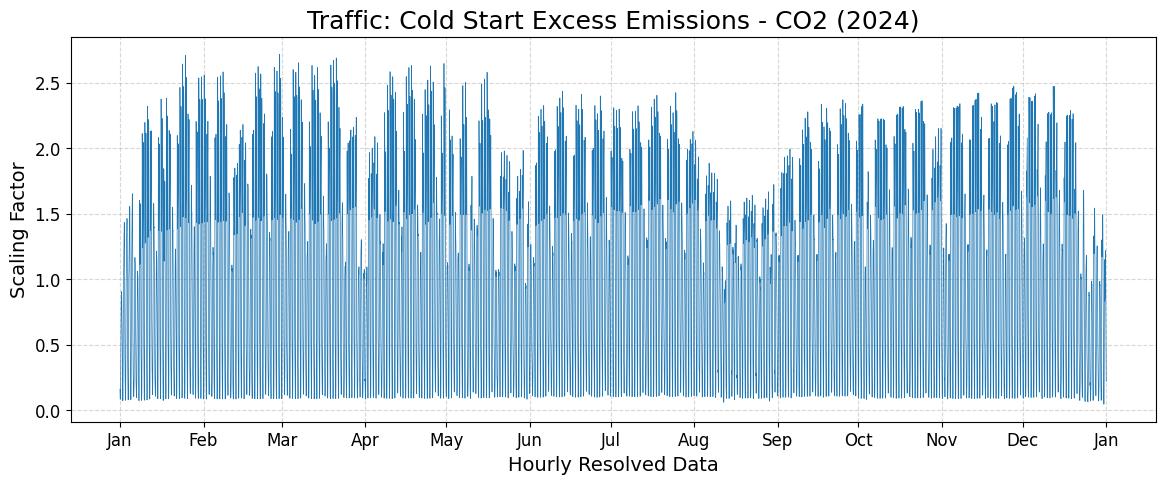

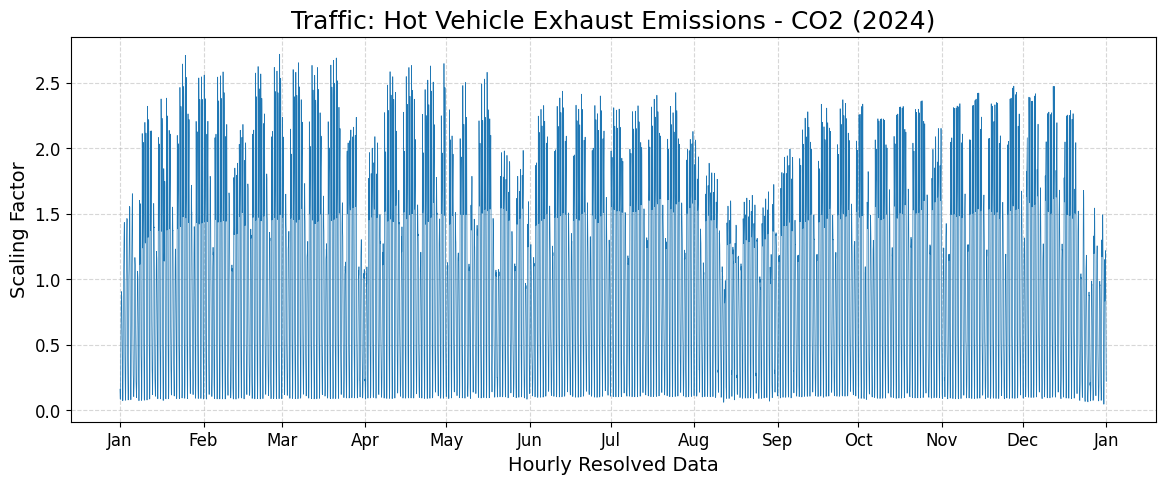

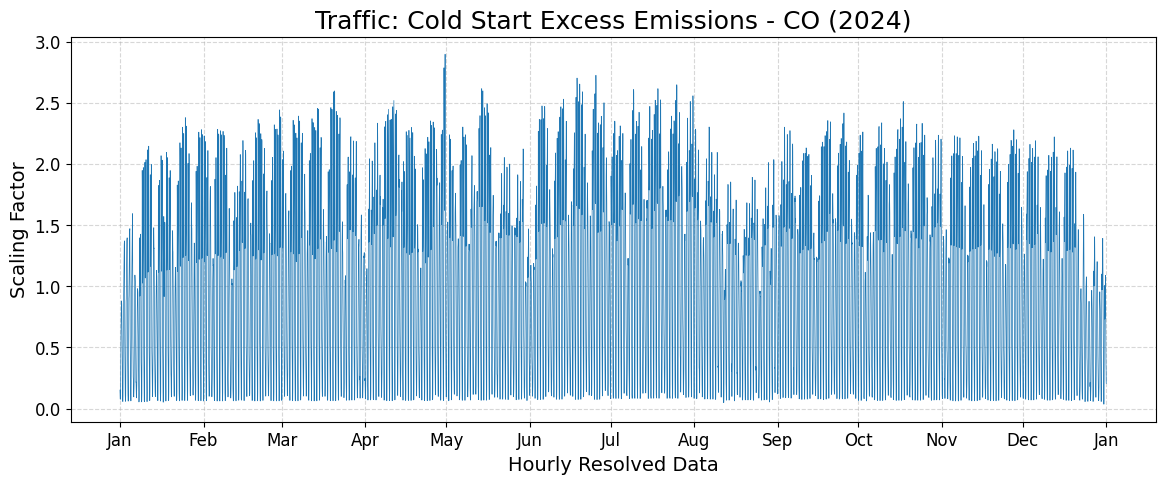

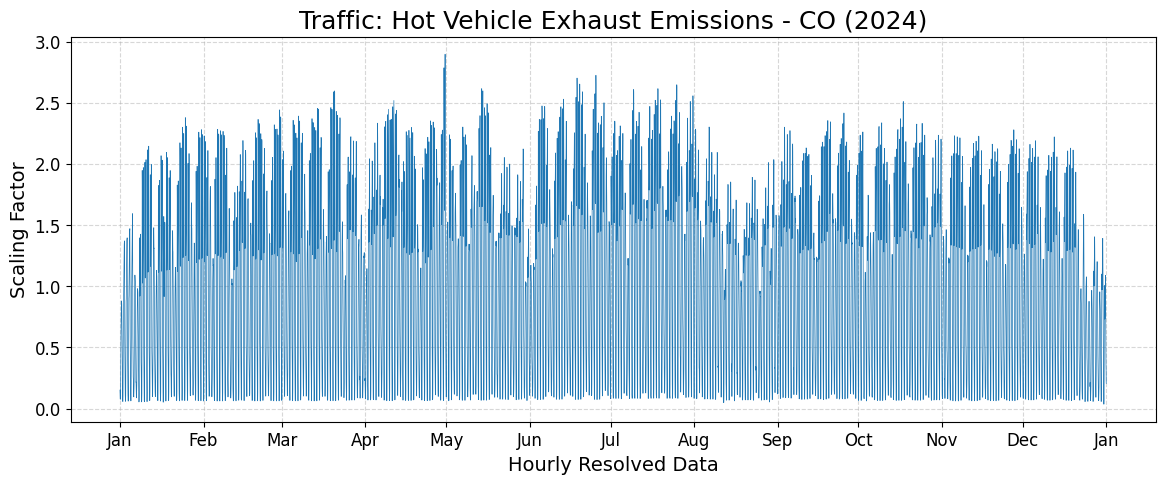

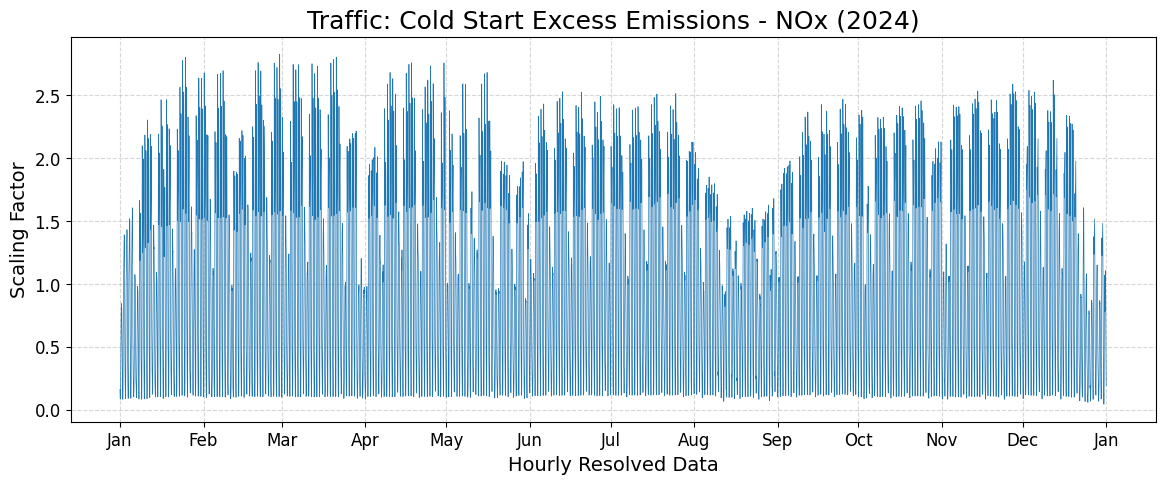

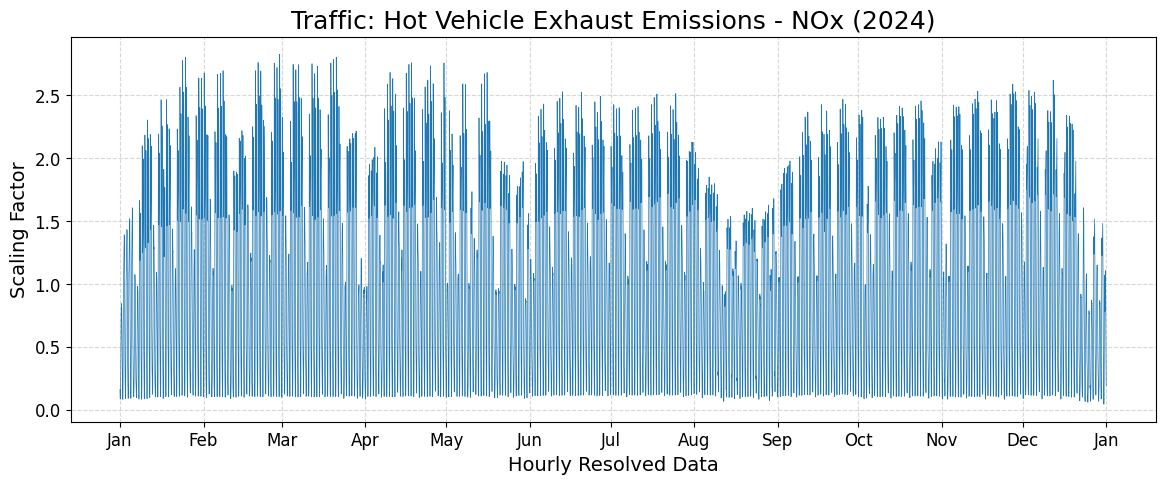

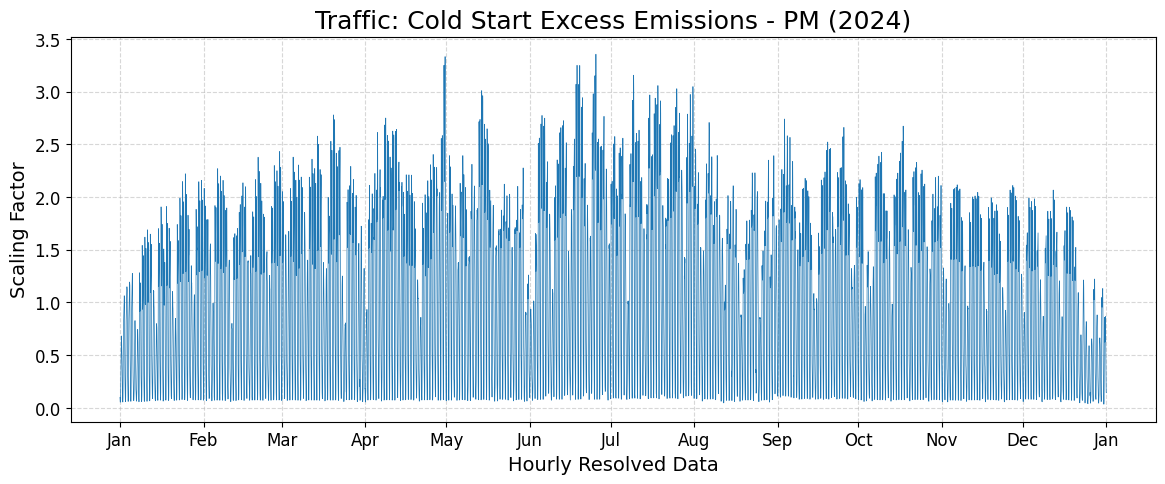

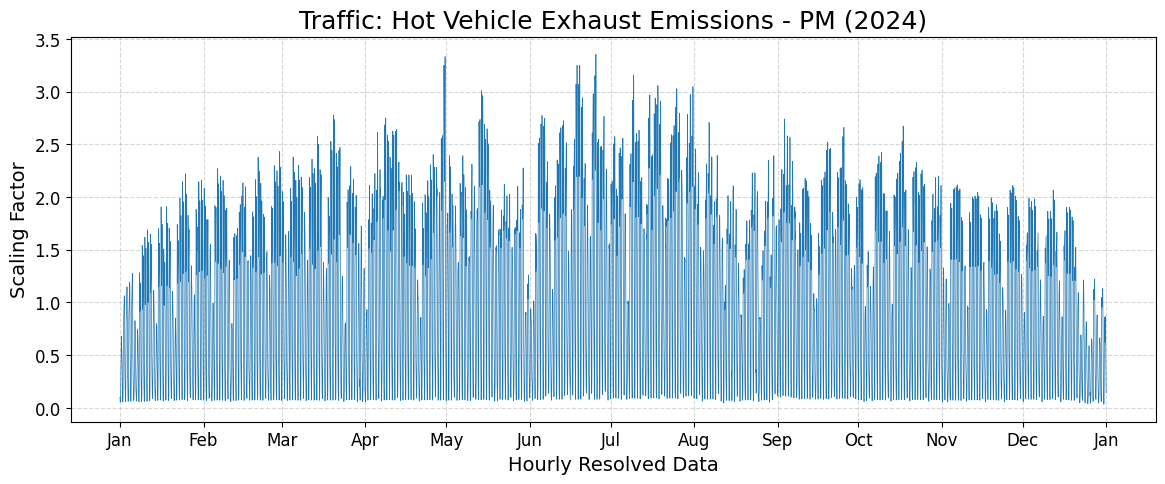

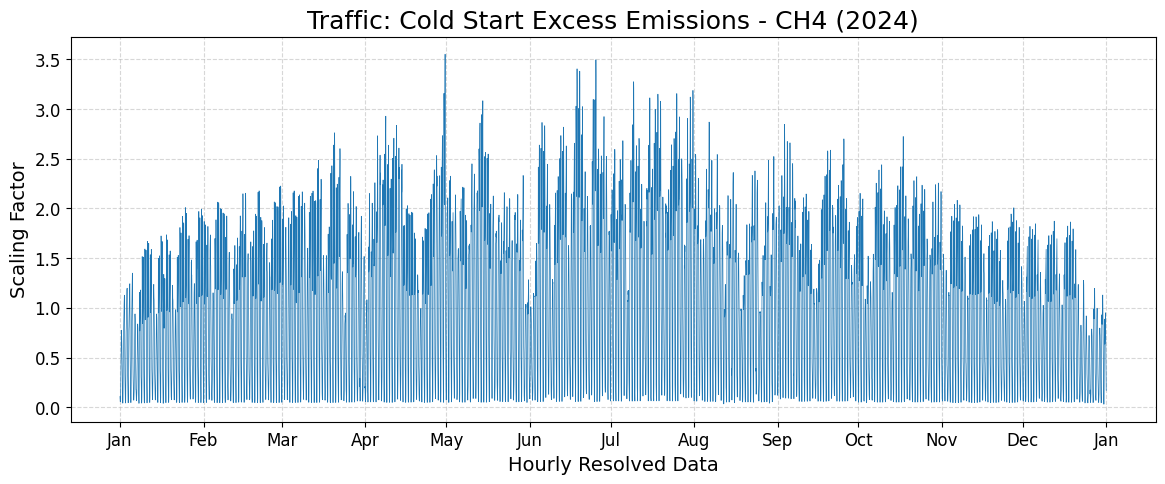

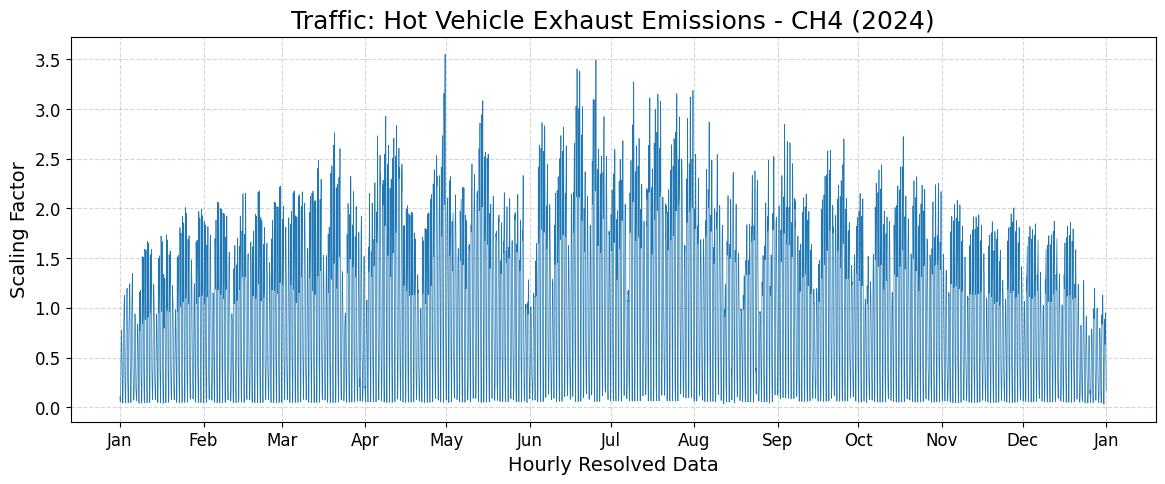

In [64]:
for component in components:
    df_plot = df_csee.filter(pl.col("component") == component)
    
    if component == "CO2(total)":
        component_1 = "CO2"
    else:
        component_1 = component

    export_png(df_plot, "scaling_factor", year, path_output, f"Traffic: Cold Start Excess Emissions - {component_1}", component, "csee")

    df_plot = df_hot.filter(pl.col("component") == component)
    export_png(df_plot, "scaling_factor", year, path_output, f"Traffic: Hot Vehicle Exhaust Emissions - {component_1}", component, "hot")
    